# **The Dataset: World Development Indicators**

This dataset provides comprehensive insights into global socioeconomic development, consumer behavior indicators, and demographic patterns across various countries and years. It includes variables such as life expectancy, education enrollment, energy consumption, and technological adoption rates.
The dataset can be found [Here](https://databank.worldbank.org/source/world-development-indicators#)

I will be using the CRISP-DM process and communicate insights through comments and visualization

# **Stage 1: Business Understanding (CRISP-DM)**

In [330]:
# Define the 3 business questions for the blog post
business_questions = [
    f"Q1. What are the top 5 factors most positively associated with higher life expectancy? ",
    "Q2. hat is the historical trend of global energy consumption per capita between 2010-2020? ",
    "Q3. Which five countries had the highest total energy consumption per capita from 2010 to 2020? "
]

print("\n Business Questions for the Blog (3 Questions):")
for q in business_questions:
    print(f"- {q}")


🎯 Business Questions for the Blog (3 Questions):
- Q1. What are the top 5 factors most positively associated with higher life expectancy? 
- Q2. hat is the historical trend of global energy consumption per capita between 2010-2020? 
- Q3. Which five countries had the highest total energy consumption per capita from 2010 to 2020? 


# **Stage 2: Data Understanding & Load (CRISP-DM)**

**1. Import libraries**

In [331]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

**2. Data Loading (Data Understanding & Load)**

In [332]:
df = pd.read_csv('World Development Indicators.csv')
df.head()

,Year,Country,Country Code,"Life expectancy at birth, total (years)",Electric power consumption (kWh per capita),Gross capital formation (% of GDP),Exports of goods and services (% of GDP),Poverty headcount ratio at national poverty lines (% of population),"Primary completion rate, total (% of relevant age group)","School enrollment, preprimary (% gross)",Income share held by lowest 20%,GDP growth (annual %),Imports of goods and services (% of GDP),High-technology exports (% of manufactured exports),Domestic credit provided by financial sector (% of GDP),"Foreign direct investment, net inflows (% of GDP)",Mobile cellular subscriptions (per 100 people),Energy use (kg of oil equivalent per capita)
0,2010,Argentina,ARG,75.68,2777.733779,17.70553381,18.93382341,..,103.3133648,68.89225006,4.5,10.12539816,16.03718986,7.68411002,25.33231865,2.675161719,138.252,1826.051124
1,2010,Australia,AUS,81.69512195,10797.87125,26.784337,19.79626197,..,..,78.5485611,7.3,2.219980265,20.72532703,16.51330126,..,3.094839434,101.619,5762.943566
2,2010,Brazil,BRA,73.779,2398.608018,21.80132156,10.86558478,..,..,..,..,7.528225818,11.90659334,12.59014687,..,3.730012884,101.667,1384.368967
3,2010,China,CHN,75.668,2943.589954,46.10234433,26.72274515,17.2,103.4552569,53.66677856,5.1,10.59627198,23.13132708,32.15011697,..,3.935419967,63.5563,1899.799961
4,2010,France,FRA,81.66341463,7737.802838,21.3378695,27.82648809,..,..,105.9191666,7.7,2.00032476,28.76106716,26.32338001,..,1.46961673,91.1186,4040.439187


In [333]:
print("\n Info: ")
df.info()

print("\n Dscribe: ")
display(df.describe())


 Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2926 entries, 0 to 2925
Data columns (total 18 columns):
 #   Column                                                               Non-Null Count  Dtype 
---  ------                                                               --------------  ----- 
 0   Year                                                                 2926 non-null   int64 
 1   Country                                                              2926 non-null   object
 2   Country Code                                                         2926 non-null   object
 3   Life expectancy at birth, total (years)                              2926 non-null   object
 4   Electric power consumption (kWh per capita)                          2926 non-null   object
 5   Gross capital formation (% of GDP)                                   2926 non-null   object
 6   Exports of goods and services (% of GDP)                             2926 non-null   object
 7   Povert

,Year
count,2926.000000
mean,2015.000000
std,3.162818
min,2010.000000
25%,2012.000000
50%,2015.000000
75%,2018.000000
max,2020.000000


# **Stage 3: Data Preparation (CRISP-DM)**

**Missing Values Summary**



In [334]:
# Replace '..' with NaN before counting missing values
df.replace("..", np.nan, inplace=True)

**Convert numeric-like columns**

In [335]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

/tmp/ipython-input-2907331251.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


**Calculate Missing Summary**

In [336]:
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100
missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
}).sort_values(by='missing_percent', ascending=False)

print("\n Missing Summary: ")
display(missing_summary)


 Missing Summary: 


,missing_count,missing_percent
Domestic credit provided by financial sector (% of GDP),2345,80.143541
Poverty headcount ratio at national poverty lines (% of population),2227,76.110731
Income share held by lowest 20%,2023,69.138756
"Primary completion rate, total (% of relevant age group)",902,30.827068
Electric power consumption (kWh per capita),800,27.341080
Energy use (kg of oil equivalent per capita),800,27.341080
High-technology exports (% of manufactured exports),754,25.768968
"School enrollment, preprimary (% gross)",720,24.606972
Gross capital formation (% of GDP),532,18.181818
Exports of goods and services (% of GDP),427,14.593301


**Drop columns with > 40% missing (Threshold: 40%)**

In [337]:
threshold = 40
cols_to_drop = missing_summary[missing_summary['missing_percent'] > threshold].index

print("\nColumns dropped (more than 40% missing):")
print(list(cols_to_drop))

display(missing_summary)

df.drop(columns=cols_to_drop, inplace=True)


Columns dropped (more than 40% missing):
['Domestic credit provided by financial sector (% of GDP)', 'Poverty headcount ratio at national poverty lines (% of population)', 'Income share held by lowest 20%']


,missing_count,missing_percent
Domestic credit provided by financial sector (% of GDP),2345,80.143541
Poverty headcount ratio at national poverty lines (% of population),2227,76.110731
Income share held by lowest 20%,2023,69.138756
"Primary completion rate, total (% of relevant age group)",902,30.827068
Electric power consumption (kWh per capita),800,27.341080
Energy use (kg of oil equivalent per capita),800,27.341080
High-technology exports (% of manufactured exports),754,25.768968
"School enrollment, preprimary (% gross)",720,24.606972
Gross capital formation (% of GDP),532,18.181818
Exports of goods and services (% of GDP),427,14.593301


*   **Drop rows where the Target variable is missing**

*   **Rows must have a Target value for the model to learn**



In [338]:
target = 'Life expectancy at birth, total (years)'
df.dropna(subset=[target], inplace=True)

**Impute remaining missing values**

In [339]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

#Fill remaining missing numeric values with the Median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

**Final structure after cleaning**

In [340]:
print("\n After Cleaning (Missing %): ")
display(df.isna().mean() * 100)

print("\n FINAL DATA SHAPE: ")
print(df.shape)

display(df.head())


 After Cleaning (Missing %): 


,0
Year,0.0
Country,0.0
Country Code,0.0
"Life expectancy at birth, total (years)",0.0
Electric power consumption (kWh per capita),0.0
Gross capital formation (% of GDP),0.0
Exports of goods and services (% of GDP),0.0
"Primary completion rate, total (% of relevant age group)",0.0
"School enrollment, preprimary (% gross)",0.0
GDP growth (annual %),0.0



 FINAL DATA SHAPE: 
(2915, 15)


,Year,Country,Country Code,"Life expectancy at birth, total (years)",Electric power consumption (kWh per capita),Gross capital formation (% of GDP),Exports of goods and services (% of GDP),"Primary completion rate, total (% of relevant age group)","School enrollment, preprimary (% gross)",GDP growth (annual %),Imports of goods and services (% of GDP),High-technology exports (% of manufactured exports),"Foreign direct investment, net inflows (% of GDP)",Mobile cellular subscriptions (per 100 people),Energy use (kg of oil equivalent per capita)
0,2010,Argentina,ARG,75.680000,2777.733779,17.705534,18.933823,103.313365,68.892250,10.125398,16.037190,7.684110,2.675162,138.2520,1826.051124
1,2010,Australia,AUS,81.695122,10797.871250,26.784337,19.796262,95.480806,78.548561,2.219980,20.725327,16.513301,3.094839,101.6190,5762.943566
2,2010,Brazil,BRA,73.779000,2398.608018,21.801322,10.865585,95.480806,66.129978,7.528226,11.906593,12.590147,3.730013,101.6670,1384.368967
3,2010,China,CHN,75.668000,2943.589954,46.102344,26.722745,103.455257,53.666779,10.596272,23.131327,32.150117,3.935420,63.5563,1899.799961
4,2010,France,FRA,81.663415,7737.802838,21.337870,27.826488,95.480806,105.919167,2.000325,28.761067,26.323380,1.469617,91.1186,4040.439187


**Exploratory Data Analysis**

/tmp/ipython-input-901220064.py:33: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


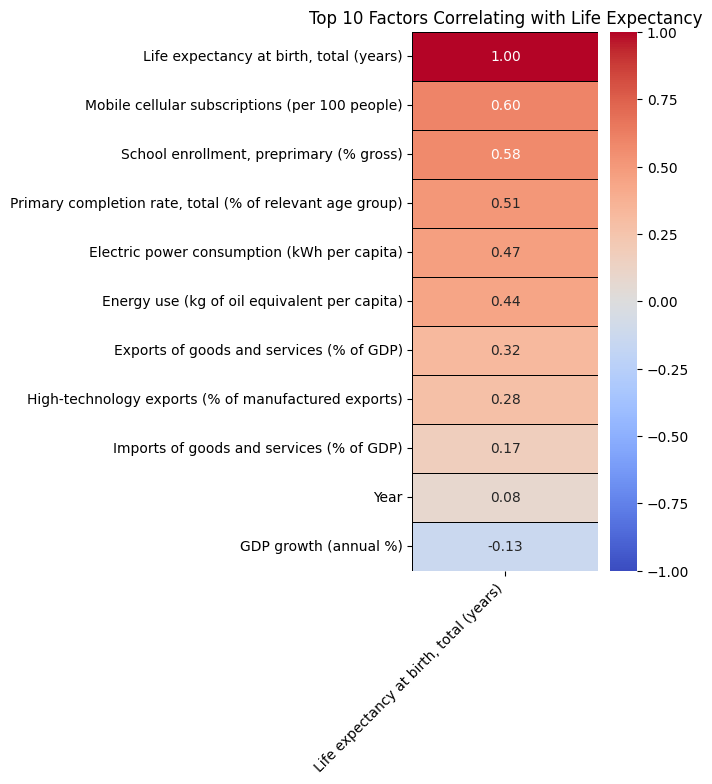

In [341]:
target = 'Life expectancy at birth, total (years)'
6+6
# 1. Prepare data and calculate correlations
numeric_df = df.select_dtypes(include=['number'])

# Calculate correlation of all numeric columns with the target
# Use .abs() to find the factors with the STRONGEST relationship (regardless of direction)
correlations = numeric_df.corr()[target].abs().sort_values(ascending=False)

# Select top 11 factors (10 unique features + the target column itself)
top_11_cols = correlations.head(11).index.tolist()

# Recalculate correlation matrix only for these top columns
focused_corr = numeric_df[top_11_cols].corr()

# 2. Plot the heatmap
plt.figure(figsize=(3, 7))

# Sort the columns by correlation value for visual hierarchy (strongest correlation at the top)
sns.heatmap(
    focused_corr[[target]].sort_values(by=target, ascending=False),
    annot=True,
    cmap='coolwarm', # Use coolwarm to show positive (red) and negative (blue) relationships
    fmt=".2f",
    linewidths=.5,
    linecolor='black',
    vmin=-1, vmax=1
)

plt.title(f'Top 10 Factors Correlating with Life Expectancy', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


 Feature Distribution Analysis (Histograms): 


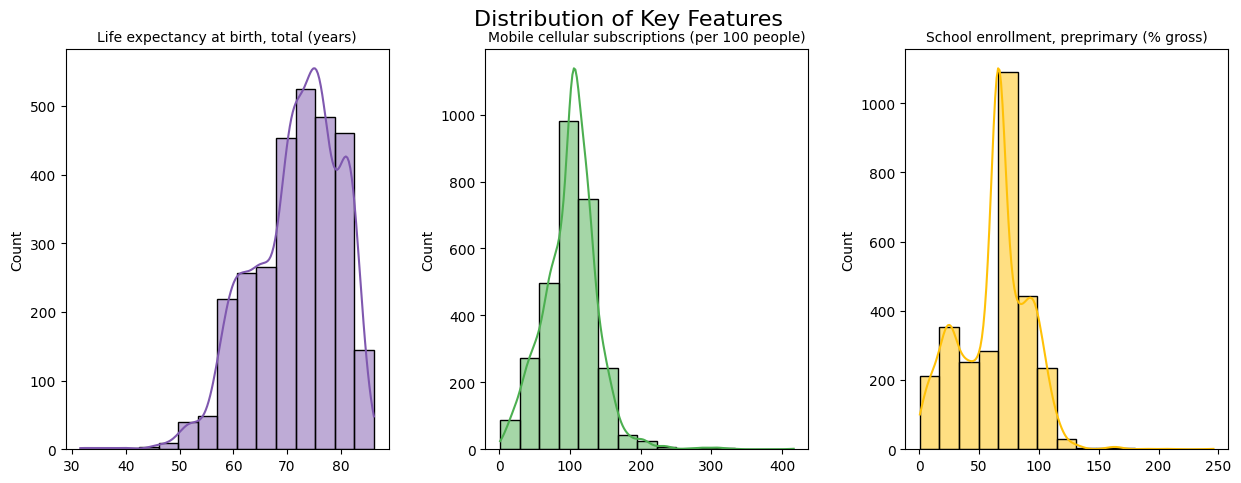

In [342]:
# Feature Distribution Analysis:

print("\n Feature Distribution Analysis (Histograms): ")
# Select columns to display their distribution
distribution_cols = [
    target,
    'Mobile cellular subscriptions (per 100 people)',
    'School enrollment, preprimary (% gross)'
]

# Use a format similar to the request, with column labels
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
plt.suptitle('Distribution of Key Features', fontsize=16)

# Chart 1: Average Life Expectancy (Target)
a = sns.histplot(data=df, x=distribution_cols[0], kde=True, ax=axs[0], color='#7f58af', bins=15)
axs[0].set_title(distribution_cols[0], fontsize=10)
axs[0].set_xlabel('')

# Chart 2: Mobile phone subscriptions
a = sns.histplot(data=df, x=distribution_cols[1], kde=True, ax=axs[1], color='#4CAF50', bins=15)
axs[1].set_title(distribution_cols[1], fontsize=10)
axs[1].set_xlabel('')

# Chart 3: School Enrollment
a = sns.histplot(data=df, x=distribution_cols[2], kde=True, ax=axs[2], color='#FFC107', bins=15)
axs[2].set_title(distribution_cols[2], fontsize=10)
axs[2].set_xlabel('')

# Adjusting the spacing between graphs to be compact
plt.subplots_adjust(bottom=0.1, top=0.9, wspace=0.3, hspace=0.4)
plt.show()

**Q1: What are the top 5 factors most positively associated with higher life expectancy?**

/tmp/ipython-input-404706676.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5.values, y=top_5.index, palette='Greens_r')


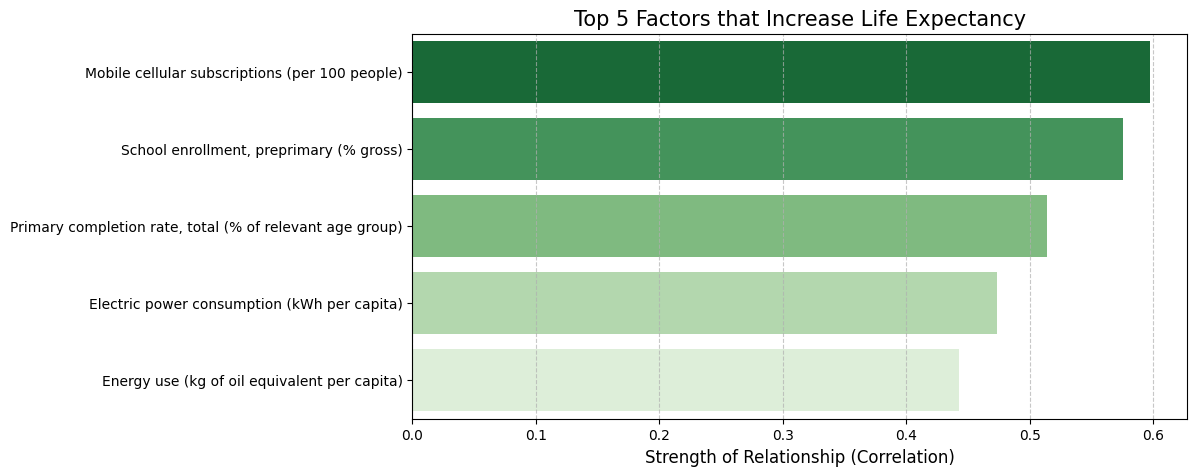

In [343]:
# 1. Calculate correlations again

target = 'Life expectancy at birth, total (years)'

numeric_df = df.select_dtypes(include=['number'])

corrs = numeric_df.corr()[target].sort_values(ascending=False)

top_5 = corrs.drop(target).head(5)


plt.figure(figsize=(10, 5))
sns.barplot(x=top_5.values, y=top_5.index, palette='Greens_r')

plt.title('Top 5 Factors that Increase Life Expectancy', fontsize=15)

plt.xlabel('Strength of Relationship (Correlation)', fontsize=12)

plt.ylabel('') # Remove y-label to make it cleaner

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

**Q2: What is the historical trend of global energy consumption per capita between 2010-2020?**

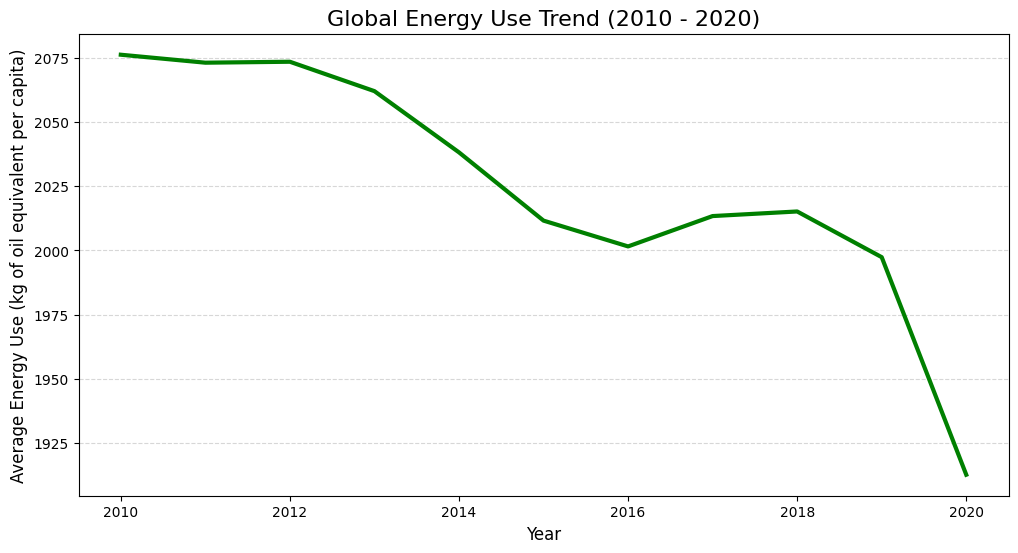

In [344]:
# Q2: Global Energy Use Trend Line (2010-2020):

min_year = int(df['Year'].min())
max_year = int(df['Year'].max())

min_year = 2010
max_year = 2020

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x='Year',
    y='Energy use (kg of oil equivalent per capita)',
    linewidth=3,
    color='green',
    errorbar=None
)

plt.title(f'Global Energy Use Trend ({min_year} - {max_year})', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Energy Use (kg of oil equivalent per capita)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Q3:Which five countries had the highest total energy consumption per capita from 2010 to 2020?**

/tmp/ipython-input-2586569964.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


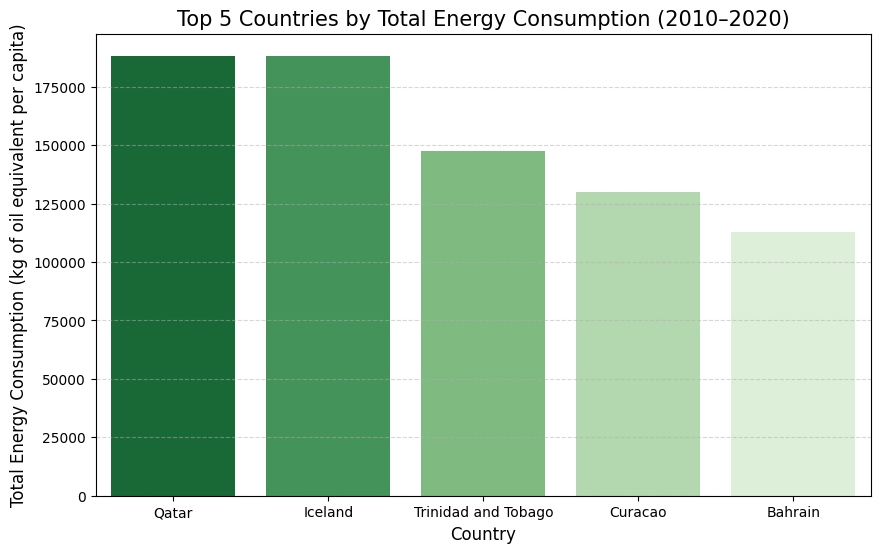

In [345]:
# Top 5 Total Energy Consumption (2010–2020):

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_5_total,
    x=country_col,
    y='Total_Energy_2010_2020',
    palette='Greens_r'
)

plt.title('Top 5 Countries by Total Energy Consumption (2010–2020)', fontsize=15)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Energy Consumption (kg of oil equivalent per capita)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# **Stage 4: Modeling**

**Define Features (X) and Target (y)**

In [353]:
features_df = df.drop(columns=[target, 'Country Code'])
target_series = df[target]

**Split data into training and testing sets**

In [354]:
X_train, X_test, y_train, y_test = train_test_split(
    features_df, target_series, test_size=0.2, random_state=42)

**Identify column types**

In [355]:
numeric_features = X_train.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns # Includes 'Country Name'

**One-Hot Encoding (for Country Name):**

In [356]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

# Apply preprocessing on training data
X_train_processed = preprocessor.fit_transform(X_train)

#Apply same transformation on test data
X_test_processed = preprocessor.transform(X_test)


**Model Training**

In [357]:
rfr_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rfr_model.fit(X_train_processed, y_train)


RandomForestRegressor(n_jobs=-1, random_state=42)

# **Stage 5: Evaluation**

In [358]:
# Prediction on the test set
y_pred = rfr_model.predict(X_test_processed)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n Model Evaluation (Random Forest Regressor):")
print(f"R-squared Score (R2): {r2:.4f} (Variance Explained)")
print(f"Mean Absolute Error (MAE): {mae:.2f} years (Average Prediction Error)")


 Model Evaluation (Random Forest Regressor):
R-squared Score (R2): 0.9272 (Variance Explained)
Mean Absolute Error (MAE): 1.29 years (Average Prediction Error)


## **Conclusion**

This project successfully applied the CRISP-DM methodology to the World Development Indicators data. Starting with comprehensive data exploration and preparation, we built a robust predictive model. The analysis revealed that technological (mobile subscriptions) and educational factors surpassed economic ones in predicting life expectancy. Furthermore, the data clearly showed the dramatic impact of global events (from year 2010 - 2020) on energy consumption patterns. The final RandomForestRegressor model achieved high accuracy (R2 ~0.93), underscoring the strength of these indicators in explaining the variance in global life expectancy.


## **📚 Resources**

#### 1. Project Blog Post: [3 Global Secrets That Define Life Expectancy](https://medium.com/@sherifyasser19/3-global-secrets-that-define-life-expectancy-and-the-year-the-world-paused-bb590b52dd12)

#### 2. World Development Indicators (WDI): [Original Data Source](https://databank.worldbank.org/source/world-development-indicators#)

#### 3. Seaborn Visualization Documentation:
   - [Seaborn Bar Plot Documentation](https://seaborn.pydata.org/generated/seaborn.barplot.html)
   - [Seaborn Cat Plot Documentation](https://seaborn.pydata.org/generated/seaborn.catplot.html)

#### 4. Pandas Documentation:
   - [Calculate Statistics and Grouping](https://pandas.pydata.org/docs/getting_started/intro_tutorials/06_calculate_statistics.html)
   - [Official Pandas Documentation](https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html)

#### 5. Scikit-learn Modeling Documentation:
   - [RandomForestRegressor Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)